In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv(r'C:\Users\Acer\OneDrive\Desktop\road_network.csv')
print(df.head())
df.info()



   road_id      road_name       road_type  length_km  lanes  speed_limit_kmh  \
0  RD-0001  Jl. Segment 1  Jalan Kolektor        4.3      4               60   
1  RD-0002  Jl. Segment 2    Jalan Arteri        4.3      4               80   
2  RD-0003  Jl. Segment 3     Jalan Lokal        1.8      2               40   
3  RD-0004  Jl. Segment 4  Jalan Kolektor        1.8      4               60   
4  RD-0005  Jl. Segment 5       Jalan Tol       22.7      4               80   

   capacity_vehicles_per_hour  has_bus_lane  has_bike_lane surface_condition  \
0                        5384             0              0             Cukup   
1                        6132             0              0              Baik   
2                         978             0              0             Cukup   
3                        4160             0              1       Rusak Berat   
4                        6600             1              0              Baik   

  last_maintenance_date  latitude_star

Environment Setup and Data Loading:

In this initial step, we import the required data manipulation (`pandas`) and visualization (`matplotlib`, `seaborn`) libraries. We then load the raw `road_network.csv` dataset from its local file path and perform an introductory inspection using `.head()` and `.info()`.

In [10]:
df.isnull().sum()
df.duplicated().sum()

np.int64(0)

Checking for Missing Values and Duplicates:

Before cleaning our data, we perform an assessment to identify missing entries using `isnull().sum()`or exact row duplicates using `duplicated().sum() `across the entire dataset. This serves as the foundation for our data cleaning decisions.

In [11]:
# Convert the maintenance date column to datetime format
df['last_maintenance_date'] = pd.to_datetime(df['last_maintenance_date'])

# Verify the change worked (it should now show datetime64)
print(df['last_maintenance_date'].dtype)

datetime64[us]


Data Type Correction:

Based on our structural inspection, the `last_maintenance_date` column was originally loaded as a generic text/string object. To enable reliable time-based operations, we explicitly cast this column into a proper `datetime64` format.

In [12]:
print("--- Numerical Summary ---")
print(df[['length_km', 'speed_limit_kmh', 'avg_daily_traffic']].describe())



--- Numerical Summary ---
       length_km  speed_limit_kmh  avg_daily_traffic
count  200.00000       200.000000         200.000000
mean     5.99450        57.200000        5497.510000
std      6.07204        29.161825        5264.646678
min      0.30000        20.000000         353.000000
25%      1.90000        40.000000        1167.750000
50%      3.05000        50.000000        3675.000000
75%      8.35000        80.000000        8847.250000
max     24.10000       120.000000       28394.000000


Summary Statistics and Visualizations

Now that our data integrity has been verified and data types are corrected, we generate descriptive summary statistics for our key attributes and visualize the distributions to glean preliminary insights.

In [13]:
# Statistic 3: Distribution of road types or surface conditions
print("\n--- Road Type Counts ---")
print(df['road_type'].value_counts())


--- Road Type Counts ---
road_type
Jalan Tol           48
Jalan Lingkungan    46
Jalan Kolektor      44
Jalan Lokal         33
Jalan Arteri        29
Name: count, dtype: int64


Text(0, 0.5, 'Frequency')

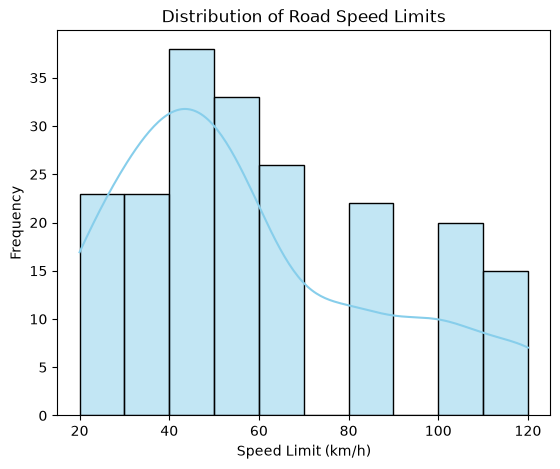

In [14]:
# Create a figure to hold both plots side-by-side
plt.figure(figsize=(14, 5))

# Plot 1: Histogram of Speed Limits
plt.subplot(1, 2, 1)
sns.histplot(df['speed_limit_kmh'], bins=10, kde=True, color='skyblue')
plt.title('Distribution of Road Speed Limits')
plt.xlabel('Speed Limit (km/h)')
plt.ylabel('Frequency')



C:\Users\Acer\AppData\Local\Temp\ipykernel_8140\341719082.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='surface_condition', palette='viridis')


Text(0, 0.5, 'Number of Roads')

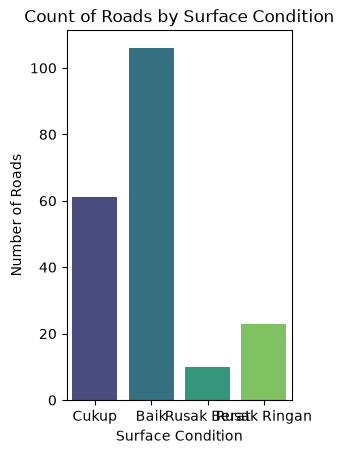

In [15]:
# Plot 2: Bar Chart of Surface Conditions
plt.subplot(1, 2, 2)
sns.countplot(data=df, x='surface_condition', palette='viridis')
plt.title('Count of Roads by Surface Condition')
plt.xlabel('Surface Condition')
plt.ylabel('Number of Roads')



In [16]:
# Adjust layout and display
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

# Week 1: Road Network Data Cleaning and EDA

## Data Cleaning Choices
* **Duplicates:** Checked for duplicate rows using `df.duplicated().sum()` and found 0 duplicates.
* **Missing Values:** Checked for null values using `df.isnull().sum()`. The dataset is fully populated, so no imputation (mean/median filling) was required.
* **Data Types:** Converted `last_maintenance_date` from a string object to a proper `datetime64` format.

## Key Observations
* The average daily traffic across the dataset shows a wide variance.
* Most of the road segments have an active speed limit between 40 km/h and 80 km/h.